# Grouping Data with Pandas

Grouping Data Frames
- Grouping Data in Pandas


- Code Example: Grouping and Comparing Penguin Data

In [1]:
import pandas as pd

In [2]:
penguins_adelie = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx601-examples/refs/heads/main/data/palmer-penguins-adelie.csv", index_col="Sample Number")
penguins_gentoo = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx601-examples/refs/heads/main/data/palmer-penguins-gentoo.csv", index_col="Sample Number")
penguins_chinstrap = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx601-examples/refs/heads/main/data/palmer-penguins-chinstrap.csv", index_col="Sample Number")

- The separate data sets have the same columns, so we will just concatenate them into one data frame.

In [3]:
penguins = pd.concat([penguins_adelie, penguins_gentoo, penguins_chinstrap])

- Pandas grouping functionality is based around the data frame method groupby.

In [4]:
species_groups = penguins.groupby("Species")
species_groups

- Usually groupby is called with a column name or list of columns like this.
- There are a few other options such as passing in a dictionary or a function mapping index labels to groups.

In [5]:
len(species_groups)

3

- There are three distinct Species values.
- That checks out since we combined three files, and each was supposed to have a different species in it.
- We can take a peak into which rows went into each group.

In [6]:
species_groups.groups

{'Adelie Penguin (Pygoscelis adeliae)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, ...], 'Chinstrap penguin (Pygoscelis antarctica)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68], 'Gentoo penguin (Pygoscelis papua)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56

- Using the groupby object, we can calculate statistics for each group.

In [7]:
species_groups.mean(numeric_only=True)

,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
Species,,,,,,
Adelie Penguin (Pygoscelis adeliae),38.791391,18.346358,189.953642,3700.662252,8.859733,-25.804194
Chinstrap penguin (Pygoscelis antarctica),48.833824,18.420588,195.823529,3733.088235,9.356155,-24.546542
Gentoo penguin (Pygoscelis papua),47.504878,14.982114,217.186992,5076.016260,8.245338,-26.185298


- The numeric_only option that I used there was to filter out columns such as Sex and Comments that don't make sense when taking an average.
- I'd like to point out that the index on this data frame is now the Species values from the original data frame, since the grouping was on that column.

,0
Species,
Adelie Penguin (Pygoscelis adeliae),"Axes(0.125,0.11;0.775x0.77)"
Chinstrap penguin (Pygoscelis antarctica),"Axes(0.125,0.11;0.775x0.77)"
Gentoo penguin (Pygoscelis papua),"Axes(0.125,0.11;0.775x0.77)"


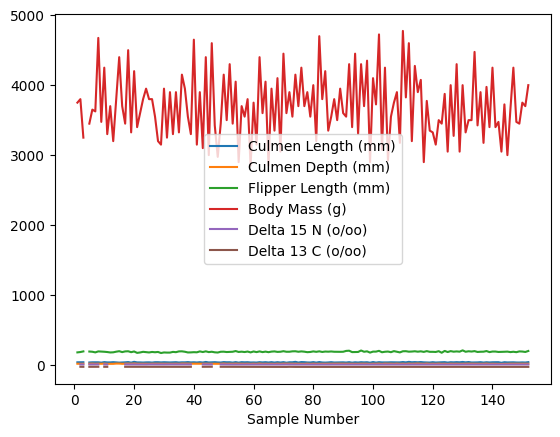

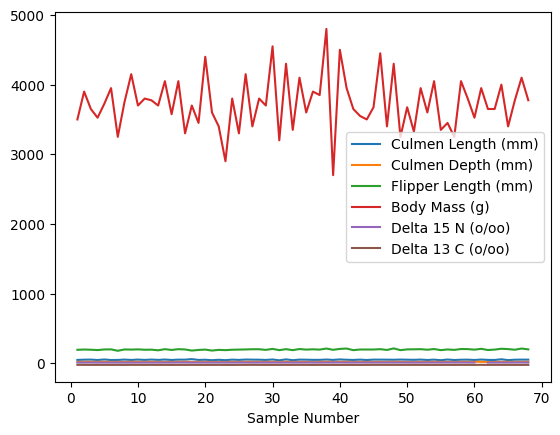

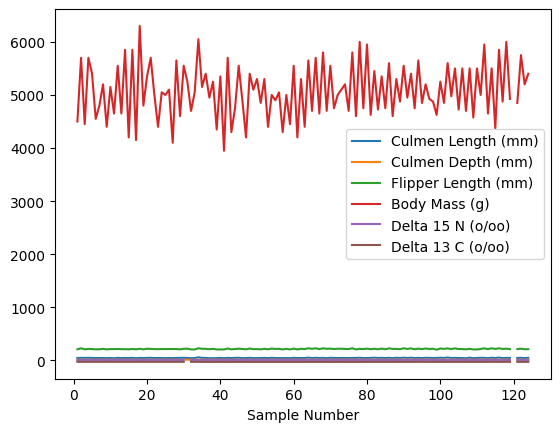

In [8]:

species_groups.plot()

In [9]:
species_groups.describe()

Culmen Length (mm)             \
                                                       count       mean   
Species                                                                   
Adelie Penguin (Pygoscelis adeliae)                    151.0  38.791391   
Chinstrap penguin (Pygoscelis antarctica)               68.0  48.833824   
Gentoo penguin (Pygoscelis papua)                      123.0  47.504878   

                                                                         \
                                                std   min    25%    50%   
Species                                                                   
Adelie Penguin (Pygoscelis adeliae)        2.663405  32.1  36.75  38.80   
Chinstrap penguin (Pygoscelis antarctica)  3.339256  40.9  46.35  49.55   
Gentoo penguin (Pygoscelis papua)          3.081857  40.9  45.30  47.30   

                                                        Culmen Depth (mm)  \
                                              75%   max             count   
Species                                                                     
Adelie Penguin (Pygoscelis adeliae)        40.750  46.0             151.0   
Chinstrap penguin (Pygoscelis antarctica)  51.075  58.0              68.0   
Gentoo penguin (Pygoscelis papua)          49.550  59.6             123.0   

                                                      ... Delta 15 N (o/oo)  \
                                                mean  ...               75%   
Species                                               ...                     
Adelie Penguin (Pygoscelis adeliae)        18.346358  ...          9.153080   
Chinstrap penguin (Pygoscelis antarctica)  18.420588  ...          9.620455   
Gentoo penguin (Pygoscelis papua)          14.982114  ...          8.418402   

                                                    Delta 13 C (o/oo)  \
                                                max             count   
Species                                                                 
Adelie Penguin (Pygoscelis adeliae)         9.79532             141.0   
Chinstrap penguin (Pygoscelis antarctica)  10.02544              68.0   
Gentoo penguin (Pygoscelis papua)           8.83352             122.0   

                                                                          \
                                                mean       std       min   
Species                                                                    
Adelie Penguin (Pygoscelis adeliae)       -25.804194  0.588186 -26.78958   
Chinstrap penguin (Pygoscelis antarctica) -24.546542  0.238809 -25.14550   
Gentoo penguin (Pygoscelis papua)         -26.185298  0.538554 -27.01854   

                                                                            \
                                                 25%        50%        75%   
Species                                                                      
Adelie Penguin (Pygoscelis adeliae)       -26.230270 -25.976960 -25.298050   
Chinstrap penguin (Pygoscelis antarctica) -24.685153 -24.572375 -24.400333   
Gentoo penguin (Pygoscelis papua)         -26.690912 -26.221575 -25.640160   

                                                     
                                                max  
Species                                              
Adelie Penguin (Pygoscelis adeliae)       -23.90309  
Chinstrap penguin (Pygoscelis antarctica) -23.78767  
Gentoo penguin (Pygoscelis papua)         -25.00169  

[3 rows x 48 columns]

In [10]:
species_groups["Body Mass (g)"].describe()

,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Adelie Penguin (Pygoscelis adeliae),151.0,3700.662252,458.566126,2850.0,3350.0,3700.0,4000.0,4775.0
Chinstrap penguin (Pygoscelis antarctica),68.0,3733.088235,384.335081,2700.0,3487.5,3700.0,3950.0,4800.0
Gentoo penguin (Pygoscelis papua),123.0,5076.016260,504.116237,3950.0,4700.0,5000.0,5500.0,6300.0


In [11]:
#Pandas code used for data aggregation
#groupby(["Species", "Sex"]): This splits the DataFrame into groups based on the unique combinations of values in the "Species" column and the "Sex" column.
#.mean(numeric_only=True): This calculates the arithmetic mean (average) for all numeric columns within each of those created groups. The numeric_only=True argument ensures that only columns containing numerical data are included in the mean calculation, ignoring text or categorical columns.
penguins.groupby(["Species", "Sex"]).mean(numeric_only=True)

Culmen Length (mm)  \
Species                                   Sex                          
Adelie Penguin (Pygoscelis adeliae)       FEMALE           37.257534   
                                          MALE             40.390411   
Chinstrap penguin (Pygoscelis antarctica) FEMALE           46.573529   
                                          MALE             51.094118   
Gentoo penguin (Pygoscelis papua)         .                44.500000   
                                          FEMALE           45.563793   
                                          MALE             49.473770   

                                                  Culmen Depth (mm)  \
Species                                   Sex                         
Adelie Penguin (Pygoscelis adeliae)       FEMALE          17.621918   
                                          MALE            19.072603   
Chinstrap penguin (Pygoscelis antarctica) FEMALE          17.588235   
                                          MALE            19.252941   
Gentoo penguin (Pygoscelis papua)         .               15.700000   
                                          FEMALE          14.237931   
                                          MALE            15.718033   

                                                  Flipper Length (mm)  \
Species                                   Sex                           
Adelie Penguin (Pygoscelis adeliae)       FEMALE           187.794521   
                                          MALE             192.410959   
Chinstrap penguin (Pygoscelis antarctica) FEMALE           191.735294   
                                          MALE             199.911765   
Gentoo penguin (Pygoscelis papua)         .                217.000000   
                                          FEMALE           212.706897   
                                          MALE             221.540984   

                                                  Body Mass (g)  \
Species                                   Sex                     
Adelie Penguin (Pygoscelis adeliae)       FEMALE    3368.835616   
                                          MALE      4043.493151   
Chinstrap penguin (Pygoscelis antarctica) FEMALE    3527.205882   
                                          MALE      3938.970588   
Gentoo penguin (Pygoscelis papua)         .         4875.000000   
                                          FEMALE    4679.741379   
                                          MALE      5484.836066   

                                                  Delta 15 N (o/oo)  \
Species                                   Sex                         
Adelie Penguin (Pygoscelis adeliae)       FEMALE           8.793275   
                                          MALE             8.928437   
Chinstrap penguin (Pygoscelis antarctica) FEMALE           9.250962   
                                          MALE             9.464535   
Gentoo penguin (Pygoscelis papua)         .                8.041110   
                                          FEMALE           8.193405   
                                          MALE             8.303429   

                                                  Delta 13 C (o/oo)  
Species                                   Sex                        
Adelie Penguin (Pygoscelis adeliae)       FEMALE         -25.794158  
                                          MALE           -25.833813  
Chinstrap penguin (Pygoscelis antarctica) FEMALE         -24.565405  
                                          MALE           -24.527679  
Gentoo penguin (Pygoscelis papua)         .              -26.184440  
                                          FEMALE         -26.197205  
                                          MALE           -26.170608

In [12]:
#Panda series method used to quickly find and display all the distinct, non-repeating values present in the "Sex" column of the dataframe
penguins["Sex"].unique()

array(['MALE', 'FEMALE', nan, '.'], dtype=object)

In [13]:
#Pandas code used for data filtering
#Select and return only the rows from the penguins DataFrame where the value in the "Sex" column is not equal to either 'MALE' or 'FEMALE'
penguins.query("Sex not in ('MALE', 'FEMALE')")

,studyName,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
Sample Number,,,,,,,,,,,,,,,,
4,PAL0708,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
9,PAL0708,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N5A1,Yes,2007-11-09,34.1,18.1,193.0,3475.0,NaN,NaN,NaN,No blood sample obtained.
10,PAL0708,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N5A2,Yes,2007-11-09,42.0,20.2,190.0,4250.0,NaN,9.13362,-25.09368,No blood sample obtained for sexing.
11,PAL0708,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N6A1,Yes,2007-11-09,37.8,17.1,186.0,3300.0,NaN,8.63243,-25.21315,No blood sample obtained for sexing.
12,PAL0708,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N6A2,Yes,2007-11-09,37.8,17.3,180.0,3700.0,NaN,NaN,NaN,No blood sample obtained.
48,PAL0708,Adelie Penguin (Pygoscelis adeliae),Anvers,Dream,"Adult, 1 Egg Stage",N29A2,Yes,2007-11-13,37.5,18.9,179.0,2975.0,NaN,NaN,NaN,Sexing primers did not amplify. Not enough blo...
27,PAL0708,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N46A1,Yes,2007-11-29,44.5,14.3,216.0,4100.0,NaN,7.96621,-25.69327,Sexing primers did not amplify.
67,PAL0809,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N51A1,Yes,2008-11-09,46.2,14.4,214.0,4650.0,NaN,8.24253,-26.81540,Sexing primers did not amplify.
105,PAL0910,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N24A1,Yes,2009-12-01,47.3,13.8,216.0,4725.0,NaN,8.25818,-26.23886,Sexing primers did not amplify.


In [14]:
penguins.query("Sex not in ('MALE', 'FEMALE')").groupby("Comments").size()

,0
Comments,
Adult not sampled.,1
Adult not sampled. Nest never observed with full clutch.,1
No blood sample obtained for sexing.,2
No blood sample obtained.,2
Sexing primers did not amplify.,4
Sexing primers did not amplify. Not enough blood for isotopes.,1


- Group By for Exploration
  - Grouping data makes it easier to see bigger trends and variation.
    - Works best with few groups.
  - Pandas groupby ignores rows with missing values by default, so there is a potential blind spot.
    - Disable that behavor with dropna=False.
- Grouping on only one column will hide interactions between variables.

- Group By: Split- Apply- Combine
  - Splitting the data into groups based on some criteria.
  - Applying a function to each group independently
    - Aggregation: compute a summary statistic (or statistics) for each group
      - i.e: compute group sums or means, compute group sizes/ counts
    - Transformation: perform some group-specific computations and return a like-indexed object
      - i.e: standardize data (zscore) within a group, filling NAs within groups with a value dervied from each group
    - Filtration: discard some groups, according to a group-wise computation that evalutates to True or False
      - i.e.: Discard data that belongs to groups with only a few members, Filter out data based on the group sum or mean
  - Combining the results into a data structure.

- Aggregation and Grouping


In [15]:
import numpy as np
import pandas as pd

class display(object):
    """Display HTML representation of multiple objects"""
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self, *args):
        self.args = args

    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                         for a in self.args)

    def __repr__(self):
        return '\n\n'.join(a + '\n' + repr(eval(a))
                           for a in self.args)

In [16]:
import seaborn as sns #widely used Python data visualization library based on Matplotlib
planets = sns.load_dataset('planets')
planets.shape

(1035, 6)

In [17]:
planets.head() #method in Pandas used to display the first n rows of a dataframe or series. if no argument is passed, shows the first 5 rows.

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


- Simple Aggregation in Pandas
  - As with a one-dimensional NumPy array, for a Pandas Series the aggregates return a single value:

In [18]:
#reproducible random number generator and then creating a Panda Series from the random numbers it generates
rng = np.random.RandomState(42)#This creates an instance of a Random Number Generator object named rng, seeding it with the integer 42. Using a specific seed like this ensures that the sequence of "random" numbers generated is deterministic (i.e., repeatable).
ser = pd.Series(rng.rand(5))#rng.rand(5)-This calls the rand method on the seeded generator object, which returns a NumPy array of 5 uniformly distributed random numbers between 0 (inclusive) and 1 (exclusive). #ser=pd.Series()- This takes the resulting NumPy array and converts it into a Pandas Series. The default index will be the integers 0 through 4.
ser #displays the variable shows the final Series object

,0
0,0.374540
1,0.950714
2,0.731994
3,0.598658
4,0.156019


In [19]:
ser.sum()

np.float64(2.811925491708157)

In [20]:
ser.mean()

np.float64(0.5623850983416314)

In [21]:
df = pd.DataFrame({'A': rng.rand(5), #calls the random number generator (rng) to produce 5 random numbers and assigns them to column A
                   'B': rng.rand(5)}) #random sequence continues from where it left off, the next 5 random numbers
df

,A,B
0,0.155995,0.020584
1,0.058084,0.969910
2,0.866176,0.832443
3,0.601115,0.212339
4,0.708073,0.181825


In [22]:
df.mean()

,0
A,0.477888
B,0.443420


- By specifying the axis argument, you can instead aggregate within each row:

In [23]:
df.mean(axis='columns')

,0
0,0.088290
1,0.513997
2,0.849309
3,0.406727
4,0.444949


- Pandas Series and DataFrames include all of the common aggregates; in addition, there is a convenience method describe() that computes several common aggregates for each column and returns the result.

In [24]:
planets.dropna().describe() #dropping rows with missing values

,number,orbital_period,mass,distance,year
count,498.00000,498.000000,498.000000,498.000000,498.000000
mean,1.73494,835.778671,2.509320,52.068213,2007.377510
std,1.17572,1469.128259,3.636274,46.596041,4.167284
min,1.00000,1.328300,0.003600,1.350000,1989.000000
25%,1.00000,38.272250,0.212500,24.497500,2005.000000
50%,1.00000,357.000000,1.245000,39.940000,2009.000000
75%,2.00000,999.600000,2.867500,59.332500,2011.000000
max,6.00000,17337.500000,25.000000,354.000000,2014.000000


Aggregation	Description
- count()--> Total number of items
- first(), last()-->	First and last item
- mean(), median()-->	Mean and median
min(), max()-->	Minimum and maximum
std(), var()-->	Standard deviation and variance
mad()-->	Mean absolute deviation
prod()-->	Product of all items
sum()-->	Sum of all items

- These are all methods of DataFrame and Series objects.

- groupby operation, which allows you to quickly and efficiently compute aggregates on subsets of data.

- GroupBy: Split, Apply, Combine
  - Aggregate conditionally on some label or index: this is implemented in the so-called groupby operation. The name "group by" comes from a command in the SQL database language, but it is perhaps more illuminative to think of it in the terms first coined by Hadley Wickham of Rstats fame: split, apply, combine.

- Split, Apply, Combine
  - The split step involves breaking up and grouping a DataFrame depending on the value of the specified key.
  - The apply step involves computing some function, usually an aggregate, transformation, or filtering, within the individual groups.
  - The combine step merges the results of these operations into an output array.

  - the intermediate splits do not need to be explicitly instantiated. Rather, the GroupBy can (often) do this in a single pass over the data, updating the sum, mean, count, min, or other aggregate for each group along the way. The power of the GroupBy is that it abstracts away these steps: the user need not think about how the computation is done under the hood, but rather thinks about the operation as a whole.

In [25]:
df = pd.DataFrame({'key': ['A', 'B', 'C', 'A', 'B', 'C'],
                   'data': range(6)}, columns=['key', 'data'])
df

,key,data
0,A,0
1,B,1
2,C,2
3,A,3
4,B,4
5,C,5


In [26]:
df.groupby('key')

In [27]:
df.groupby('key').sum()

,data
key,
A,3
B,5
C,7


- The GroupBy Object
  - aggregate, filter, transform, and apply
  - Column Indexing
    - GroupBy object supports column indexing in the same way as the DataFrame, and returns a modified GroupBy object.


In [28]:
planets.groupby('method')

In [29]:
planets.groupby('method')['orbital_period']

-  As with the GroupBy object, no computation is done until we call some aggregate on the object:

In [30]:
planets.groupby('method')['orbital_period'].median()

,orbital_period
method,
Astrometry,631.180000
Eclipse Timing Variations,4343.500000
Imaging,27500.000000
Microlensing,3300.000000
Orbital Brightness Modulation,0.342887
Pulsar Timing,66.541900
Pulsation Timing Variations,1170.000000
Radial Velocity,360.200000
Transit,5.714932


- Iteration over groups
  - The GroupBy object supports direct iteration over the groups, returning each group as a Series or DataFrame:

In [31]:
for (method, group) in planets.groupby('method'):#for (method, group) in- starts a loop that goes through each of those piles one by one #planets.groupby('method')- this steps tells the computer to sort and group all the rows in your spreadsheet based on what is written in the 'method' column
    print("{0:30s} shape={1}".format(method, group.shape)) #group.shape- checks the size of the pile

Astrometry                     shape=(2, 6)
Eclipse Timing Variations      shape=(9, 6)
Imaging                        shape=(38, 6)
Microlensing                   shape=(23, 6)
Orbital Brightness Modulation  shape=(3, 6)
Pulsar Timing                  shape=(5, 6)
Pulsation Timing Variations    shape=(1, 6)
Radial Velocity                shape=(553, 6)
Transit                        shape=(397, 6)
Transit Timing Variations      shape=(4, 6)


- Dispatch Methods
  - Any method not explicitly implemented by the GroupBy object will be passed through and called on the groups, whether they are DataFrame or Series objects

In [32]:
planets.groupby('method')['year'].describe().unstack() #unstack()- pivot or rotate data from a row-level index to a column-level structure

method                       
count  Astrometry                          2.0
       Eclipse Timing Variations           9.0
       Imaging                            38.0
       Microlensing                       23.0
       Orbital Brightness Modulation       3.0
                                         ...  
max    Pulsar Timing                    2011.0
       Pulsation Timing Variations      2007.0
       Radial Velocity                  2014.0
       Transit                          2014.0
       Transit Timing Variations        2014.0
Length: 80, dtype: float64

- Dipatch methods applied to each individual group, and the results are then combined within GroupBy and returned. Again, any valid DataFrame/Series method can be used on the corresponding GroupBy object, which allows for some very flexible and powerful operations!

- Aggregate, Filter, Transform, Apply
  - GroupBy objects have aggregate(), filter(), transform(), and apply() methods that efficiently implement a variety of useful operations before combining the grouped data.

In [33]:
rng = np.random.RandomState(0) #reproducible random number generator in NumPy
                   'data1': range(6),
                   'data2': rng.randint(0, 10, 6)},
                   columns = ['key', 'data1', 'data2'])
df

#.random- submodule inside NumPy specifically dedicated to functions and classes for generating random numbers
#.RandomState- class name within the module
#Essentially, you are telling Python: "Go into the NumPy library (np), find the random number tools (.random), and give me a specific, seeded random generator machine (.RandomState(0))."

,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9


- Aggregation
  - Can take a string, a function, or a list thereof, and compute all the aggregates at once

In [34]:
df.groupby('key').aggregate(['min', np.median, max])

/tmp/ipython-input-968873422.py:1: FutureWarning: The provided callable <function median at 0x7f491858c540> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df.groupby('key').aggregate(['min', np.median, max])
/tmp/ipython-input-968873422.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df.groupby('key').aggregate(['min', np.median, max])


data1            data2           
      min median max   min median max
key                                  
A       0    1.5   3     3    4.0   5
B       1    2.5   4     0    3.5   7
C       2    3.5   5     3    6.0   9

In [35]:
df.groupby('key').aggregate({'data1': 'min',
                             'data2': 'max'})

,data1,data2
key,,
A,0,5
B,1,7
C,2,9


- Filtering
  -  Allows you to drop data based on the group properties. For example, we might want to keep all groups in which the standard deviation is larger than some critical value:

In [36]:
def filter_func(x):
    return x['data2'].std() > 4

display('df', "df.groupby('key').std()", "df.groupby('key').filter(filter_func)")

df
  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9

df.groupby('key').std()
       data1     data2
key                   
A    2.12132  1.414214
B    2.12132  4.949747
C    2.12132  4.242641

df.groupby('key').filter(filter_func)
  key  data1  data2
1   B      1      0
2   C      2      3
4   B      4      7
5   C      5      9

- The filter function should return a Boolean value specifying whether the group passes the filtering. Here because group A does not have a standard deviation greater than 4, it is dropped from the result.

- Transformation
  - While aggregation must return a reduced version of the data, transformation can return some transformed version of the full data to recombine. For such a transformation, the output is the same shape as the input. A common example is to center the data by subtracting the group-wise mean:

In [37]:
df.groupby('key').transform(lambda x: x - x.mean())

,data1,data2
0,-1.5,1.0
1,-1.5,-3.5
2,-1.5,-3.0
3,1.5,-1.0
4,1.5,3.5
5,1.5,3.0


- The apply() method
  - The apply() method lets you apply an arbitrary function to the group results. The function should take a DataFrame, and return either a Pandas object (e.g., DataFrame, Series) or a scalar; the combine operation will be tailored to the type of output returned.
  - For example, here is an apply() that normalizes the first column by the sum of the second:

In [38]:
def norm_by_data2(x):
    # x is a DataFrame of group values
    x['data1'] /= x['data2'].sum() # augmented assignment operator (/=) means the operation is performed in-place
    return x

display('df', "df.groupby('key').apply(norm_by_data2)")

<string>:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
<string>:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


df
  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9

df.groupby('key').apply(norm_by_data2)
      key     data1  data2
key                       
A   0   A  0.000000      5
    3   A  0.375000      3
B   1   B  0.142857      0
    4   B  0.571429      7
C   2   C  0.166667      3
    5   C  0.416667      9

- apply() within a GroupBy is quite flexible: the only criterion is that the function takes a DataFrame and returns a Pandas object or scalar; what you do in the middle is up to you!

- Specifying the split key
  - A list, array, series, or index providing the grouping keys
  - The key can be any series or list with a length matching that of the DataFrame. For example:

In [39]:
L = [0, 1, 0, 1, 2, 0]
display('df', 'df.groupby(L).sum()')

,key,data1,data2
0,A,0,5
1,B,1,0
2,C,2,3
3,A,3,3
4,B,4,7
5,C,5,9
,key,data1,data2
0,ACC,7,17
1,BA,4,3
2,B,4,7


- Of course, this means there's another, more verbose way of accomplishing the df.groupby('key') from before:

In [40]:
display('df', "df.groupby(df['key']).sum()")

df
  key  data1  data2
0   A      0      5
1   B      1      0
2   C      2      3
3   A      3      3
4   B      4      7
5   C      5      9

df.groupby(df['key']).sum()
     data1  data2
key              
A        3      8
B        5      7
C        7     12

- A dictionary or series mapping index to group
  - Another method is to provide a dictionary that maps index values to the group keys:

In [41]:
df2 = df.set_index('key')
mapping = {'A': 'vowel', 'B': 'consonant', 'C': 'consonant'}
display('df2', 'df2.groupby(mapping).sum()')

,data1,data2
key,,
A,0,5
B,1,0
C,2,3
A,3,3
B,4,7
C,5,9
,data1,data2
key,,
consonant,12,19


- Any Python Function
  - Similar to mapping, you can pass any Python function that will input the index value and output the group:

In [42]:
display('df2', 'df2.groupby(str.lower).mean()')

,data1,data2
key,,
A,0,5
B,1,0
C,2,3
A,3,3
B,4,7
C,5,9
,data1,data2
key,,
a,1.5,4.0


- A list of valid keys
  - Further, any of the preceding key choices can be combined to group on a multi-index:

In [43]:
df2.groupby([str.lower, mapping]).mean()

,,data1,data2
key,key,,
a,vowel,1.5,4.0
b,consonant,2.5,3.5
c,consonant,3.5,6.0


- Grouping Example


In [44]:
#figures out the total count of planets found for each discovery method within each decade, and then displays the result in a clean, wide table
decade = 10 * (planets['year'] // 10)
decade = decade.astype(str) + 's'
decade.name = 'decade'
planets.groupby(['method', decade])['number'].sum().unstack().fillna(0)

decade,1980s,1990s,2000s,2010s
method,,,,
Astrometry,0.0,0.0,0.0,2.0
Eclipse Timing Variations,0.0,0.0,5.0,10.0
Imaging,0.0,0.0,29.0,21.0
Microlensing,0.0,0.0,12.0,15.0
Orbital Brightness Modulation,0.0,0.0,0.0,5.0
Pulsar Timing,0.0,9.0,1.0,1.0
Pulsation Timing Variations,0.0,0.0,1.0,0.0
Radial Velocity,1.0,52.0,475.0,424.0
Transit,0.0,0.0,64.0,712.0


- This shows the power of combining many of the operations we've discussed up to this point when looking at realistic datasets.

Key Terms:
1. Grouping: Reorganizing data around a shared feature value
2. Grouped analysis: Analysis that is repeated for each group of data, aggregating the groups data. Also called bucketed analysis.

- Loading the Data: The first step is to import pandas and load the customers.csv file into a DataFrame called customers.

- Grouping by Product Category: By using groupby("Product Category"), you organize the data into groups based on the product category column.

- Checking Groups: len(product_groups) gives you the number of product categories, and product_groups.groups provides a dictionary where keys are product category names and values are indices of rows belonging to each category.

- Performing Aggregations: You can use mean() and sum() on product_groups["Purchase Amount"] to compute average and total purchase amounts for each product category, respectively.

- When analyzing survey data with pandas, using agg() with a list (['mean', 'max', 'min']) is effective for automating the calculation of multiple statistics like mean, max, and min across different survey questions and respondent groups. This method streamlines the data analysis process by allowing you to comprehensively summarize insights without manually applying each aggregation function separately. Understanding how to leverage such pandas operations enhances your capability to conduct detailed and insightful data analyses in various research and business contexts.

# Querying Your Data (More Pandas)
- A powerful feature of most data frame implementations including pandas is the ability to query data in data frames similarly to having a database server with the data frames as tables. Pandas lets you write expressions describing what you want, and pandas takes care of the details. Furthermore, pandas has support for joining data frames, similarly to joining tables in a database query, allowing data from multiple tables to be efficiently combined. This is a very popular feature of pandas and other data frame implementations, and lets you focus on what data you are looking for instead of how to get it.


In [1]:
import pandas as pd
import sys

In [2]:
abalone = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/abalone.tsv", sep="\t")
abalone

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


- The pandas data frame query method is a convenient way to filter data.
- The query method takes in a string with a Python-like expression, and returns rows where that expression is true.
- This is very similar to a WHERE clause in a database query, but using Python instead of SQL syntax.

In [3]:
abalone.query("Sex in ('M', 'F')")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.3300,20
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [4]:
target_sexes = ['M', 'F']
abalone.query("Sex in @target_sexes")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.3300,20
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [5]:
abalone.query("Sex in @target_sexes and (Whole_weight > 0.5 or Height > 0.2)")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.3300,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.2600,16
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


- The query requirement is roughly that the expression return a Boolean value.
- If the query is a number or even a column name by itself, it will interpret the query as an index value.

In [6]:
abalone.query("4174")

,4174
Sex,M
Length,0.6
Diameter,0.475
Height,0.205
Whole_weight,1.176
Shucked_weight,0.5255
Viscera_weight,0.2875
Shell_weight,0.308
Rings,9


In [7]:
abalone.query("Sex in @target_sexes and (Whole_weight > 0.5 or Height > 0.2)")["Rings"].mean()

np.float64(11.222448149654332)

In [8]:
abalone["Rings"].mean()

np.float64(9.933684462532918)

Security Concerns with Query and Eval


In [9]:
import pandas as pd
import sys

In [10]:
abalone = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/abalone.tsv", sep="\t")

Referencing Python Variables is Convenient
- target_sexes = ['M', 'F']
- abalone.query("Sex in @target_sexes")
  - A critical part of this usage is that you pick what Python expression is accessed.
  - If you want to express Python variables, always use the @ syntax and write it out yourself.

Never Insert Outside Data in Your Query String
- If you construct your query string from someone else's data, you risk running arbitrary Python code of someone else's choice.
  - abalone.query(f"""Sex in ({','.join("'" + s + "'" for s in target_sexes})")
  - abalone.query(f"...")
  - abalone.query("... == " + user_data)

In [11]:
evil_request = "', @sys.stderr.write('hi'), '"

In [12]:
abalone.query("Sex =='" + evil_request + "'")

hi

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

- A lot can go wrong if you open yourself up to query injection.
- Data loss and credential theft are relatively easy if you execute other people's data as code.
- The key is to keep the value as a value, and not turn it into code.

In [13]:
abalone.query("Sex == @evil_request")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings


- In this example, you are referring to the value, and the pandas evaluation engine will compare to the value.
- The value will not be used as code.

Just Use @variable References
- easier to read
- easier to write
- will not execute code unexpectedly

Manual Data Frame Queries
- Compares declarative queries using pandas data frames with implementing equivalent filtering using a series of lower level data frame operations.

Code Example: Reimplementing a Query without Query


In [14]:
import pandas as pd

In [15]:
abalone = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/abalone.tsv", sep="\t")
abalone

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [16]:
abalone.query("Sex in @target_sexes and (Whole_weight > 0.5 or Height > 0.2)")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.3300,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.2600,16
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


Breaking Up the Query
- Goal:
  - Sex in @target_sexes and (Whole_weight > 0.5 or Height > 0.2)")
- Pieces:
  - Sex in @target_sexes
  - Whole_weight > 0.5
  - Height > 0.2

- The first condition can be replaced with the isin method of a pandas Series.

In [17]:
abalone["Sex"].isin(target_sexes)

,Sex
0,True
1,True
2,True
3,True
4,False
...,...
4172,True
4173,True
4174,True
4175,True


In [18]:
abalone["Whole_weight"] > 0.5

,Whole_weight
0,True
1,False
2,True
3,True
4,False
...,...
4172,True
4173,True
4174,True
4175,True


In [19]:
abalone["Height"] > 0.2

,Height
0,False
1,False
2,False
3,False
4,False
...,...
4172,False
4173,False
4174,True
4175,False


In [20]:
(abalone["Whole_weight"] > 0.5) | (abalone["Height"] > 0.2) #how to combine them- logical or will be implemented by Python's bitwise or operator, the vertical pipe.

,0
0,True
1,False
2,True
3,True
4,False
...,...
4172,True
4173,True
4174,True
4175,True


- That took in two series of booleans and returned a new series of booleans.
- We will do the same thing for the logical and, using Python's bitwise and operator, the ampersand.

In [21]:
abalone["Sex"].isin(target_sexes) & (abalone["Whole_weight"] > 0.5) | (abalone["Height"] > 0.2)

,0
0,True
1,False
2,True
3,True
4,False
...,...
4172,True
4173,True
4174,True
4175,True


- Now we have a series of booleans matching up with the original data frame, where the booleans specify whether or not we want each row.
- We can index the data frame with that series, and get just the rows that we want.

In [22]:
abalone[abalone["Sex"].isin(target_sexes) & ((abalone["Whole_weight"] > 0.5) | (abalone["Height"] > 0.2))]

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.3300,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.2600,16
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [23]:
abalone.query("Sex in @target_sexes and (Whole_weight > 0.5 or Height > 0.2)")

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
6,F,0.530,0.415,0.150,0.7775,0.2370,0.1415,0.3300,20
7,F,0.545,0.425,0.125,0.7680,0.2940,0.1495,0.2600,16
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


High-Performance Pandas: eval() and query()
- Problem: Overhead of Compound Expressions
  - Standard NumPy and Pandas vectorized operations are fast because they push work into C, but compound expressions can become inefficient.
  - In compound expressions (e.g., (x > 0.5) & (y < 0.5)), NumPy and Pandas typically evaluate each intermediate step and allocate a full temporary array for it in memory.
  - For very large arrays, this can lead to significant memory and computational overhead.

Solution: eval() and query()
- Pandas' eval() and query() functions use the Numexpr library to compute string expressions.
- Numexpr evaluates these expressions element by element without the need to allocate full-sized intermediate arrays, saving memory and time.

pandas.eval()
- The top-level function pd.eval() allows for efficient computation of expressions between multiple DataFrame objects (e.g., pd.eval('df1 + df2 + df3 + df4')).
- It supports arithmetic, comparison, and bitwise operators, as well as attribute and index access.

DataFrame.eval()
- The df.eval() method, called on a DataFrame, is more succinct and allows you to refer to column names directly as variables (e.g., df.eval('(A + B) / (C - 1)')).
- It supports assignment to create or modify a column in place (using inplace=True, e.g., df.eval('D = (A + B) / C', inplace=True)).
- It allows the use of local Python variables within the string expression by prefixing the variable name with an @ (e.g., df.eval('A + @column_mean')).

DataFrame.query()
- The df.query() method is a specialized version of eval() used for row filtering (masking) operations.
- It provides a cleaner, more readable syntax for filtering compared to traditional boolean masking (e.g., df.query('A < 0.5 and B < 0.5')).
- Like df.eval(), it also supports referencing local Python variables with the @ prefix.

Performance Considerations
- The main benefit of eval() and query() is reduced memory use, especially when temporary arrays would be a significant portion of your available system memory (i.e., several gigabytes).
- They can also offer a performance boost by avoiding slow memory movement between CPU caches (L1/L2) when temporary arrays are larger than the cache size.
- For smaller arrays, the traditional Pandas methods are often just as fast, or sometimes faster, so the benefit is primarily in memory saving and potentially cleaner syntax.

Joining Data Frames
- Combining their data based on meaningful links between their columns. Joins are a common operation in databases allowing information from different tables to be combined, and most data frame implementations have some kind of join support.
- Index Recap
  - The index is like a special column or series attached to each pandas data frame.
  - The index values identify rows in the data frame
Index values are not required to be unique
  - Uniqueness is not mandatory to avoid blowing up from common duplicate data issues, but duplicate index values tend to lead to more duplicates in derived data frames. When possible, unique index values are preferred, but sometimes real data gets in the way.
  - Panda joins use the index to select rows in the joined data frame.
-Trivial Joins
  - Combining data from different data frames is trivial if they share the same index. In that case, you can just copy over the columns. As previously mentioned, pandas will handle matching up index values, and leave NA (not available) values where there is no match.


Joining Data Frames with Pandas
- Data Frames are Joined by Index
  - The previous trivial joins worked because both data frames shared the same index.
  - The data frame join method can join from any column of the calling data frame to the index of the other data frame.
  - Key idea: searching an index is faster.


Joining Costs to Project Materials


In [1]:
import pandas as pd

In [2]:
bed_size_materials = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/garden-bed_size_materials.tsv", sep="\t")
bed_size_materials

,bed_size,material,quantity_per_bed
0,4' x 4',"2"" x 6"" x 4'",20
1,4' x 4',"8"" x 8"" x 16"" Cinder Block",12
2,4' x 8',"2"" x 6"" x 4'",6
3,4' x 8',"2"" x 6"" x 8'",14
4,4' x 8',"8"" x 8"" x 16"" Cinder Block",24


In [3]:
material_costs = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/garden-material_costs.tsv", sep="\t", index_col="material")
material_costs

,unit_cost
material,
"2"" x 6"" x 4'",4.92
"2"" x 6"" x 8'",6.62
"8"" x 8"" x 16"" Cinder Block",2.53


In [4]:
bed_size_costs = bed_size_materials.join(material_costs, on="material")
bed_size_costs

,bed_size,material,quantity_per_bed,unit_cost
0,4' x 4',"2"" x 6"" x 4'",20,4.92
1,4' x 4',"8"" x 8"" x 16"" Cinder Block",12,2.53
2,4' x 8',"2"" x 6"" x 4'",6,4.92
3,4' x 8',"2"" x 6"" x 8'",14,6.62
4,4' x 8',"8"" x 8"" x 16"" Cinder Block",24,2.53


In [6]:
bed_size_costs["cost"] = bed_size_costs["quantity_per_bed"] * bed_size_costs["unit_cost"]
bed_size_costs

,bed_size,material,quantity_per_bed,unit_cost,cost
0,4' x 4',"2"" x 6"" x 4'",20,4.92,98.40
1,4' x 4',"8"" x 8"" x 16"" Cinder Block",12,2.53,30.36
2,4' x 8',"2"" x 6"" x 4'",6,4.92,29.52
3,4' x 8',"2"" x 6"" x 8'",14,6.62,92.68
4,4' x 8',"8"" x 8"" x 16"" Cinder Block",24,2.53,60.72


In [7]:
bed_size_costs.groupby("bed_size")["cost"].sum()

,cost
bed_size,
4' x 4',128.76
4' x 8',182.92


In [8]:
bed_size_costs = bed_size_costs.groupby("bed_size")[["cost"]].sum()
bed_size_costs

,cost
bed_size,
4' x 4',128.76
4' x 8',182.92


- The core difference between a Pandas Series and a DataFrame lies in their dimensionality and structure:
  - Series: A one-dimensional (1D) labeled array. Think of it as a single column in a spreadsheet or a Python dictionary where keys are the index labels and values are the data points.
    - It has only one set of axis labels: the index.
    - All data elements in a Series must generally be of the same data type (though Pandas has extensions for mixed types).
    - It can optionally have a name.
  - DataFrame: A two-dimensional (2D) labeled data structure with columns of potentially different types. Think of it as an entire spreadsheet or a SQL table.
    - It has two sets of axis labels: the index (for rows) and columns (for column labels).
    - A DataFrame is conceptually a collection of Series objects that share the same index.

- Motivations for Joining Data
  - Generalization - Data Appends
    - Input:
      - Input data - what you are working on now
      - Append data - extra data that you want to add
        - Usually indexed on an input column
        - Usually from a different data source
    - Output:
      - Input data with new column(s) appended
      

- Structuring Tables for Joins in Pandas
  - How to use and manage data frame indexes for efficient joins in pandas.


- Code Example: Reshaping Spreadsheet Data


In [9]:
import pandas as pd

In [10]:
bed_size_materials_original = pd.read_csv("https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/garden-bed_size_materials-original.tsv", sep="\t")
bed_size_materials_original

,Bed Width (ft),Bed Length (ft),Height Target (in),Bottom Target (in),Bottom Pieces,Bottom Width (in),Height Pieces,"2"" x 6"" x 4'","2"" x 6"" x 8'","8"" x 8"" x 16"" Cinder Block"
0,4,4,18,45,8,44,3,20,0,12
1,4,8,18,45,8,44,3,6,14,24


In [11]:
bed_size_materials_original["bed_size"] = bed_size_materials_original["Bed Width (ft)"].astype("string") + "' x " + bed_size_materials_original["Bed Length (ft)"].astype('string') + "'"
bed_size_materials_original

,Bed Width (ft),Bed Length (ft),Height Target (in),Bottom Target (in),Bottom Pieces,Bottom Width (in),Height Pieces,"2"" x 6"" x 4'","2"" x 6"" x 8'","8"" x 8"" x 16"" Cinder Block",bed_size
0,4,4,18,45,8,44,3,20,0,12,4' x 4'
1,4,8,18,45,8,44,3,6,14,24,4' x 8'


In [12]:
bed_size_materials = bed_size_materials_original.melt( #.melt() function is used to unpivot a DataFrame from a wide format to a long format. This is useful for making data easier to plot or analyze in certain statistical packages.
    id_vars=["bed_size"], #identifier variable
    value_vars=[c for c in bed_size_materials_original.columns if " x " in c], #list comprehension that is unpivoted
    var_name="material",
    value_name="quantity_per_bed")
bed_size_materials

,bed_size,material,quantity_per_bed
0,4' x 4',"2"" x 6"" x 4'",20
1,4' x 8',"2"" x 6"" x 4'",6
2,4' x 4',"2"" x 6"" x 8'",0
3,4' x 8',"2"" x 6"" x 8'",14
4,4' x 4',"8"" x 8"" x 16"" Cinder Block",12
5,4' x 8',"8"" x 8"" x 16"" Cinder Block",24


In [13]:
for m in bed_size_materials["material"].unique():
    print(m)

2" x 6" x 4'
2" x 6" x 8'
8" x 8" x 16" Cinder Block


In [14]:
material_costs = pd.read_csv(
    "https://raw.githubusercontent.com/bu-cds-omds/dx602-examples/main/data/garden-material_costs.tsv",
    sep="\t",
    index_col="material")
material_costs

,unit_cost
material,
"2"" x 6"" x 4'",4.92
"2"" x 6"" x 8'",6.62
"8"" x 8"" x 16"" Cinder Block",2.53


In [15]:
bed_size_costs = bed_size_materials.join(material_costs, on="material")
bed_size_costs

,bed_size,material,quantity_per_bed,unit_cost
0,4' x 4',"2"" x 6"" x 4'",20,4.92
1,4' x 8',"2"" x 6"" x 4'",6,4.92
2,4' x 4',"2"" x 6"" x 8'",0,6.62
3,4' x 8',"2"" x 6"" x 8'",14,6.62
4,4' x 4',"8"" x 8"" x 16"" Cinder Block",12,2.53
5,4' x 8',"8"" x 8"" x 16"" Cinder Block",24,2.53


In [16]:
bed_size_costs["cost"] = bed_size_costs["quantity_per_bed"] * bed_size_costs["unit_cost"]
bed_size_costs

,bed_size,material,quantity_per_bed,unit_cost,cost
0,4' x 4',"2"" x 6"" x 4'",20,4.92,98.40
1,4' x 8',"2"" x 6"" x 4'",6,4.92,29.52
2,4' x 4',"2"" x 6"" x 8'",0,6.62,0.00
3,4' x 8',"2"" x 6"" x 8'",14,6.62,92.68
4,4' x 4',"8"" x 8"" x 16"" Cinder Block",12,2.53,30.36
5,4' x 8',"8"" x 8"" x 16"" Cinder Block",24,2.53,60.72


In [17]:
bed_size_costs = bed_size_costs.groupby("bed_size")[["cost"]].sum()
bed_size_costs

,cost
bed_size,
4' x 4',128.76
4' x 8',182.92


In [18]:
bed_size_materials.pivot_table(
    index="bed_size",
    columns="material",
    values="quantity_per_bed"
)

material,"2"" x 6"" x 4'","2"" x 6"" x 8'","8"" x 8"" x 16"" Cinder Block"
bed_size,,,
4' x 4',20.0,0.0,12.0
4' x 8',6.0,14.0,24.0


- The pivot_table method will let you reorganize rows into a table.
- Melt and pivot table- reshaping functions

- Different Join Types
  - The default behavior of the join method performs an "inner" join. The rows returned have values from both the original and other data frame. This behavior is important to note since rows from the original data frame will not be in the new data frame if there is no match in the other data frame.
  - There are four other options for the how argument controlling that join behavior. Setting how="left" will keep rows in the original data frame from being dropped, and will fill in NA where the other data frame does not have a match.

Combinging Datasets: Concat and Append
- Pandas Series and DataFrame objects using simple concatenation, primarily with the pd.concat() function and the shorthand .append() method
- Key Takeaways from pd.concat()
  - The pd.concat() function is the primary tool for straightforward, stack-wise or side-by-side concatenation of data:
    - Syntax: It is similar to NumPy's np.concatenate(), taking a list or tuple of objects to be combined, e.g., pd.concat([obj1, obj2, obj3]).
    - Axis Control: By default, it joins row-wise (axis=0), stacking one DataFrame on top of another. Setting axis=1 (or axis='col') joins column-wise, placing DataFrames side-by-side.
    - Index Preservation: Unlike NumPy concatenation, Pandas' pd.concat() preserves indices by default, which can result in duplicate index values in the combined result.
- Handling Duplicate Indices
  - The article outlines several options for managing duplicate indices, which often occur when stacking DataFrames:
    - Catching Errors: Set verify_integrity=True to raise a ValueError if the concatenation results in overlapping indices.
    - Ignoring the Index: Set ignore_index=True to discard the original indices and create a new, sequential integer index for the resulting object.
    - Adding MultiIndex Keys: Use the keys argument to assign a label to each input DataFrame. The result will have a Hierarchical Index (MultiIndex), where the keys form the outermost index level, allowing for easier data selection.
- Concatenation with Joins
  - When combining DataFrames with different sets of column names:
    - Outer Join (Default): By default, pd.concat() performs an outer join (join='outer'), which is a union of all columns from all input objects. Missing values are filled with NaN.
    - Inner Join: Setting join='inner' performs an intersection of the columns, including only those columns shared by all input objects.
- The .append() Method
  - The .append() method is a convenient shorthand for simple row-wise concatenation:
    - df1.append(df2) is equivalent to pd.concat([df1, df2]).
    - Important Note: Unlike Python list's append(), the Pandas method does not modify the original object in place; it returns a new combined object.
    - Efficiency: For multiple appends, it is generally less efficient than collecting all DataFrames into a list and passing them once to pd.concat().

Combining Datasets: Merge and Join
- Pandas pd.merge() function for high-performance, database-style join operations, which is fundamentally based on Relational Algebra. This is used to link data from two different sources based on common keys.
1. Categories of Joins
  - The type of merge performed is determined by the relationship between the key columns in the input DataFrames:
    - One-to-One Joins: A unique key in the first DataFrame matches a unique key in the second. The result combines the two sets of columns into a single row.
    - Many-to-One Joins: A unique key in one DataFrame (the "one" side) matches duplicate keys in the other (the "many" side). The resulting DataFrame will repeat the information from the "one" side for every matching row in the "many" side.
    - Many-to-Many Joins: The key column contains duplicates in both DataFrames. The result is a more complex join that computes the Cartesian product of the matching rows.
2. Specification of the Merge Key
You can explicitly control which columns or indices are used as the key for the join:
  - on: Used when the key column name is the same in both DataFrames (e.g., pd.merge(df1, df2, on='ID')).
  - left_on / right_on: Used when the key columns have different names in the two DataFrames (e.g., pd.merge(df1, df2, left_on='employee', right_on='name')).
  - left_index / right_index: Used to merge based on the DataFrame's index instead of a column.
    - The shorthand .join() method is equivalent to calling pd.merge() with left_index=True and right_index=True (it defaults to joining on indices).
3. Specifying Set Arithmetic (The how Keyword)
- The how keyword determines which rows are kept when keys are not present in both DataFrames (similar to SQL join types)
4. Overlapping Column Names
- If the DataFrames have columns other than the key that share the same name (e.g., both have a 'rank' column), pd.merge() automatically appends suffixes to the column names:
  - rank_x: The original column from the left (first) DataFrame.
  - rank_y: The original column from the right (second) DataFrame.
- You can customize these suffixes using the suffixes keyword (e.g., suffixes=['_L', '_R']).

Key Terms:
- Query: A procedure to methodically answer a question from data. Generally, this includes filtering, combining and aggregating different datasets. (The pandas data frame method is more narrow.)
- Filtering: Selecting a subset of rows from a dataset that match a particular criteria
- Joining: A process combining multiple datasets based on shared values